# XGboost

## Load all

In [5]:
from util import generate_train_test_split

X_train, X_test, y_train, y_test = generate_train_test_split()


Before SMOTE:
label
0    619054
1    213397
Name: count, dtype: int64

After SMOTE:
label
0    619054
1    619054
Name: count, dtype: int64


In [6]:
print(X_train.shape, X_test.shape)

(1238108, 15) (208113, 15)


In [7]:
print(y_train.value_counts())

label
0    619054
1    619054
Name: count, dtype: int64


## Train

In [8]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    reg_lambda=1.0,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=42
)

xgb.fit(X_train, y_train)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## Evaluations

In [9]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

y_proba = xgb.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


ROC-AUC: 0.9536911894492395
              precision    recall  f1-score   support

           0       0.94      0.93      0.93    154764
           1       0.79      0.82      0.81     53349

    accuracy                           0.90    208113
   macro avg       0.87      0.87      0.87    208113
weighted avg       0.90      0.90      0.90    208113

Confusion matrix:
 [[143429  11335]
 [  9556  43793]]


### Confusion matrix

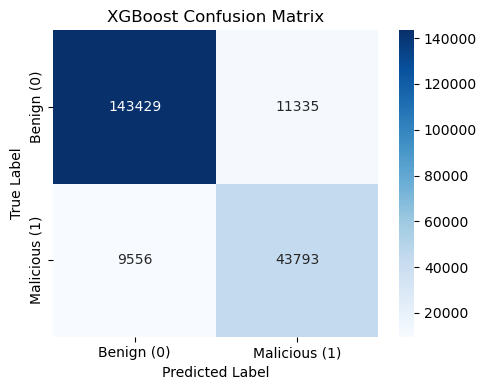

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign (0)", "Malicious (1)"],
    yticklabels=["Benign (0)", "Malicious (1)"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.show()


### Roc Curve

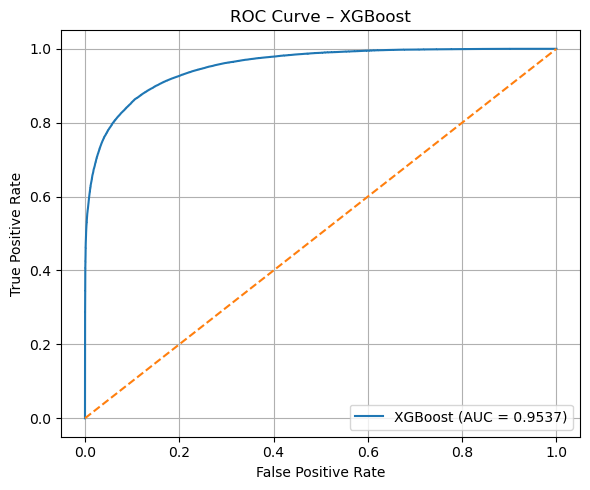

In [11]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – XGBoost")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


### Feature Importance

In [12]:
import pandas as pd

imp = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(imp.head(15))


num_slashes              0.151733
num_dots                 0.118838
path_length              0.082372
host_length              0.075862
keyword_count            0.071855
avg_path_token_length    0.062885
special_proportion       0.060417
num_digits               0.054966
num_special              0.054839
entropy                  0.053323
num_letters              0.049773
letter_proportion        0.048152
digit_proportion         0.048067
url_length               0.035924
ccr_transition           0.030993
dtype: float32


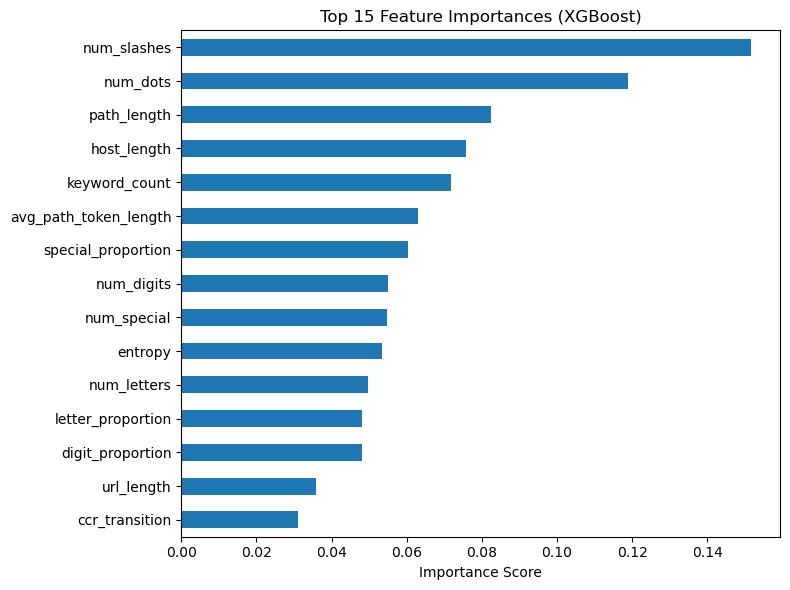

In [13]:
import pandas as pd

importances = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Top 15 Feature Importances (XGBoost)")
plt.tight_layout()
plt.show()


## Train

In [14]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Train probabilities and preds
y_train_proba = xgb.predict_proba(X_train)[:, 1]
y_train_pred  = (y_train_proba >= 0.5).astype(int)

print("TRAIN ROC-AUC:", roc_auc_score(y_train, y_train_proba))
print(classification_report(y_train, y_train_pred, digits=4))
print("TRAIN Confusion matrix:\n", confusion_matrix(y_train, y_train_pred))

TRAIN ROC-AUC: 0.9712596370234775
              precision    recall  f1-score   support

           0     0.8886    0.9288    0.9083    619054
           1     0.9254    0.8836    0.9040    619054

    accuracy                         0.9062   1238108
   macro avg     0.9070    0.9062    0.9062   1238108
weighted avg     0.9070    0.9062    0.9062   1238108

TRAIN Confusion matrix:
 [[574976  44078]
 [ 72049 547005]]


## Confusion Matrix

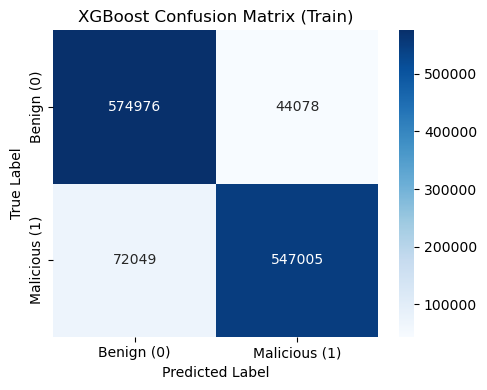

In [16]:
cm_train = confusion_matrix(y_train, y_train_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_train,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign (0)", "Malicious (1)"],
    yticklabels=["Benign (0)", "Malicious (1)"]
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("XGBoost Confusion Matrix (Train)")
plt.tight_layout()
plt.show()

## ROC

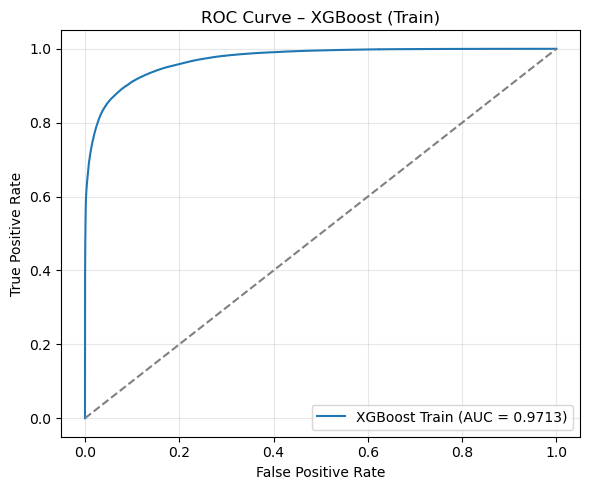

In [17]:
fpr_train, tpr_train, _ = roc_curve(y_train, y_train_proba)
roc_auc_train = auc(fpr_train, tpr_train)

plt.figure(figsize=(6,5))
plt.plot(fpr_train, tpr_train, label=f"XGBoost Train (AUC = {roc_auc_train:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – XGBoost (Train)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()